
## Checking Lexos Installation

**Purpose:**  
Ensure that the Lexos package is installed correctly and confirm its version.


### Inputs

None

### Outputs

Prints the installed Lexos version string to the console.

### Explanation

This cell simply imports the `lexos` library and then prints out its `__version__` attribute. This helps verify that the user has Lexos available in their environment and know which version is running.




In [1]:

import lexos

lexos.__version__

'0.1.0'


## Creating a Bubble Chart from Raw Text

**Purpose:**  
Generate a simple bubble chart directly from a raw text string to visualize term frequencies.


### Inputs

* `text` (str): A space-separated string of words.
* `BubbleChart` (class): Imported from `lexos.visualization.bubbleviz`.

### Outputs

Renders and displays a bubble chart titled “Fruit Term Frequencies”, showing up to 10 terms, with a figure size of 8×8 inches.

### Explanation

* We import `BubbleChart` from the Lexos bubble visualization module.
* We define `text` containing repeated fruit names.
* We initialize a `BubbleChart` object with `data=text`, which tokenizes the string and counts word occurrences.
* We call `chart(title="Fruit Term Frequencies", limit=10, figsize=(8, 8))` to render the plot with a given title, term limit, and figure dimensions.



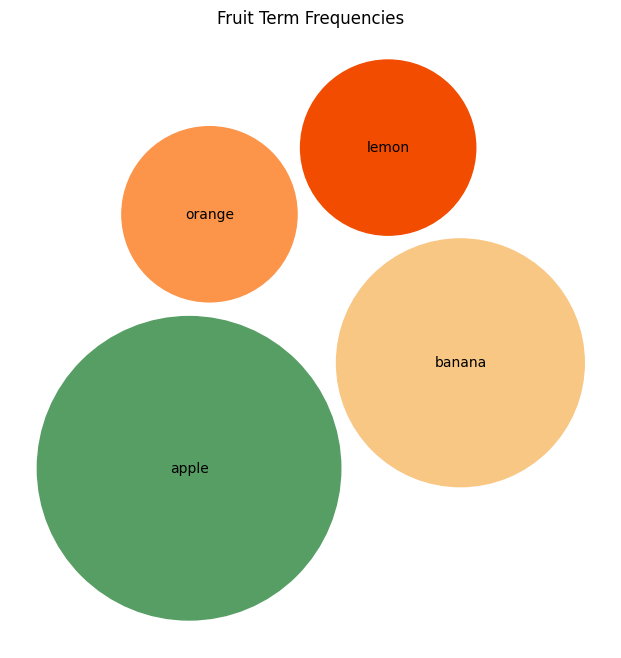

In [2]:


from lexos.visualization.bubbleviz import BubbleChart

text = "apple banana apple orange banana apple lemon"
chart = BubbleChart(data=text)
chart(title="Fruit Term Frequencies", limit=10, figsize=(8, 8))



## Generating a Bubble Chart from Manual Term Counts

**Purpose:**  
Show how to create a bubble chart using a dictionary of manually specified term frequencies.

### Inputs

* `term_counts` (dict): A mapping of terms to integer frequencies (e.g., `{"apple": 5, "banana": 3, "orange": 2, "lemon": 1}`).
* `BubbleChart` (class): Used to generate the bubble plot from frequency data.

### Outputs

Renders and displays a bubble chart titled “Manual Term Counts”, showing each term sized proportionally to its count. The `limit=10` parameter caps the maximum number of terms shown.

### Explanation

* We define a Python dictionary `term_counts` with explicit frequencies.
* Passing `data=term_counts` to `BubbleChart` uses those exact counts rather than computing from raw text.
* Calling `chart(title="Manual Term Counts", limit=10)` draws the bubble chart with the given title and term limit.




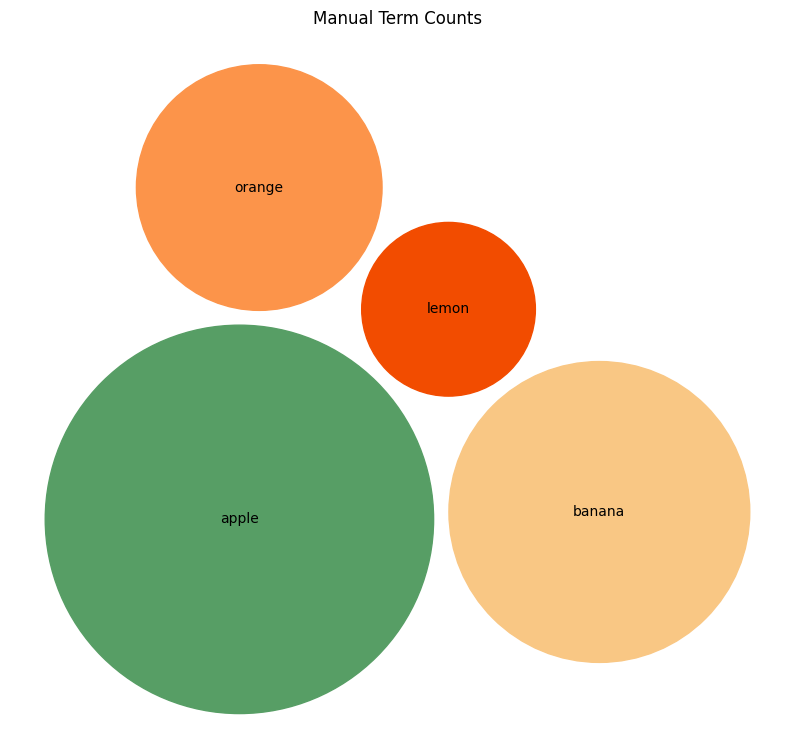

In [3]:
term_counts = {"apple": 5, "banana": 3, "orange": 2, "lemon": 1}
chart = BubbleChart(data=term_counts)
chart(title="Manual Term Counts", limit=10)



## Creating a Bubble Chart from a List of Tokens

**Purpose:**  
Demonstrate how to generate a bubble chart from a Python list of tokens, where each token is counted by frequency.

### Inputs

* `tokens` (list of str): A list of words (e.g., `["data", "science", "data", "analysis", "python", "data"]`).
* `BubbleChart` (class): Creates the bubble visualization from a list by counting occurrences.

### Outputs

Renders and displays a bubble chart titled “Token List Input”, showing the frequency of each unique token in the list.

### Explanation

* We supply a Python list of repeated terms to `BubbleChart`.
* The constructor counts how many times each token appears.
* Calling `chart(title="Token List Input")` draws the bubble chart with default figure size and styles, labeling the plot with the provided title.

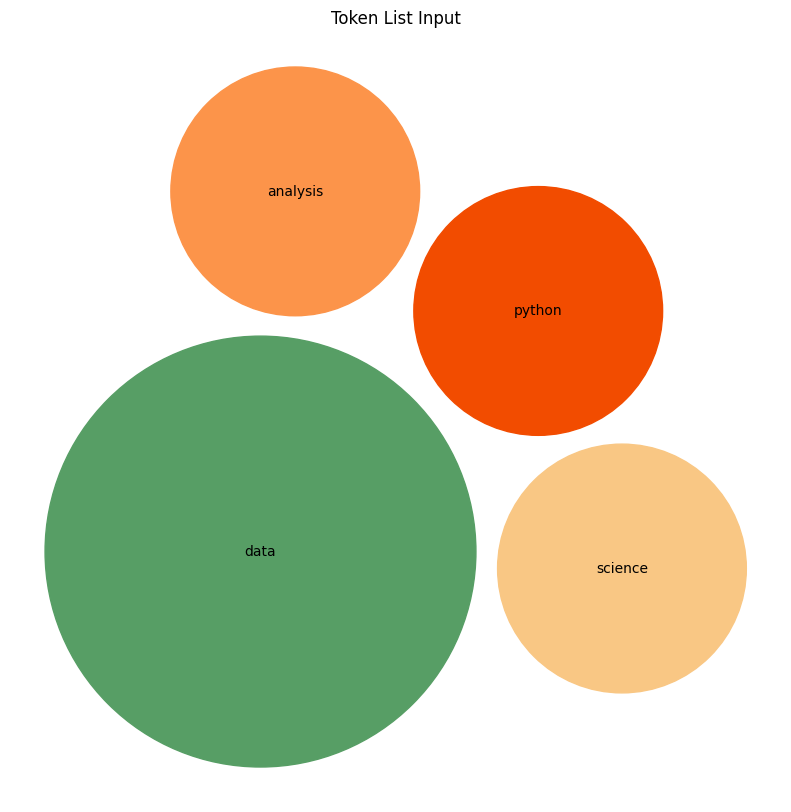

In [4]:
tokens = ["data", "science", "data", "analysis", "python", "data"]
chart = BubbleChart(data=tokens)
chart(title="Token List Input")



## Generating a Bubble Chart from a pandas DataFrame

**Purpose:**  
Illustrate how to create a bubble chart using a DataFrame that holds term frequencies for one column.


### Inputs

* `df` (pandas.DataFrame):

  * Index (terms): `"apple"`, `"banana"`, `"lemon"`.
  * Column `"Doc1"` with corresponding counts `[3, 5, 2]`.
* `docs` (str): Specifies which column in the DataFrame to visualize (here, `"Doc1"`).
* `BubbleChart` (class): Creates the bubble plot based on a DataFrame and chosen column.

### Outputs

Renders and displays a bubble chart titled “From DataFrame”, where each bubble’s size corresponds to the count of that term in `"Doc1"`.

### Explanation

* We import `pandas` and define `df` so that each row index represents a term and the cell value is its frequency.
* Passing `data=df` and `docs="Doc1"` to `BubbleChart` instructs the chart to use the counts in column `"Doc1"`.
* Calling `chart(title="From DataFrame")` draws the bubble chart for those term frequencies.



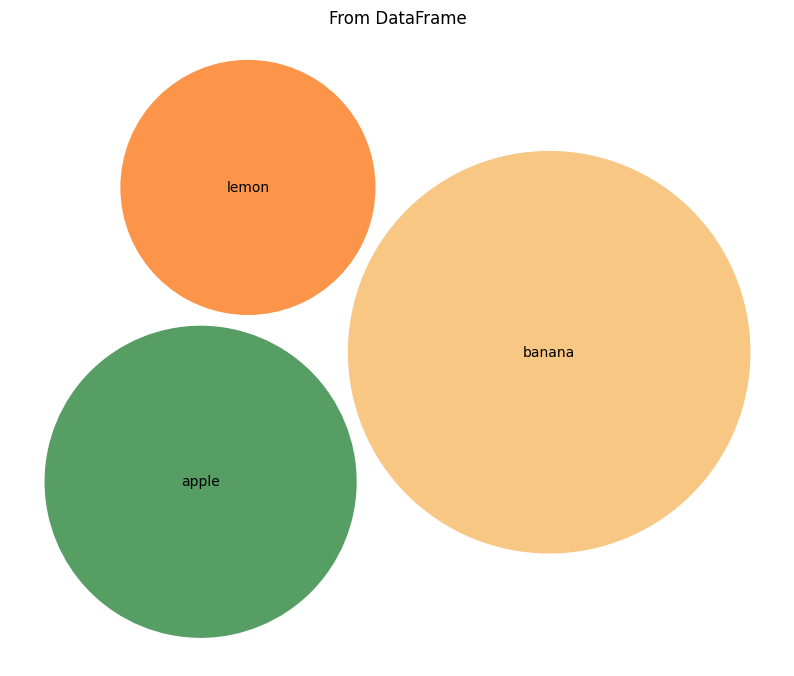

In [5]:
import pandas as pd

df = pd.DataFrame({"Doc1": [3, 5, 2]}, index=["apple", "banana", "lemon"])
chart = BubbleChart(data=df, docs="Doc1")
chart(title="From DataFrame")



## Creating a Customized Bubble Chart with Custom Colors and Options

**Purpose:**  
Show how to apply custom color mapping, font, spacing, and figure size to the bubble chart.


### Inputs

* `custom_colors` (list of str): Hex color codes for each bubble (e.g., `["#FFB6C1", "#87CEFA", "#90EE90", "#FFD700"]`).
* `text` (str): The same raw text used earlier (e.g., `"apple banana apple orange banana apple lemon"`).
* Parameters passed to `chart(...)`:

  * `title` (str): “Customized Bubble Chart”.
  * `limit` (int): Maximum of 6 terms to display.
  * `bubble_spacing` (float): Controls spacing between bubbles (0.2).
  * `colors` (list of str): Custom color palette.
  * `font_family` (str): Font used for text labels (“Arial”).
  * `figsize` (tuple): Figure size of 12×8 inches.

### Outputs

Renders and displays a bubble chart titled “Customized Bubble Chart” using the specified color list, font, spacing, term limit, and figure dimensions.

### Explanation

* We define a list `custom_colors` with four hex codes.
* We re-use the `text` string to build term frequencies.
* Calling `BubbleChart(data=text)` initializes a new chart object.
* Passing the additional keyword arguments to `chart(...)` applies custom aesthetics:

  * `limit=6` shows only the top 6 terms.
  * `bubble_spacing=0.2` slightly separates bubbles.
  * `colors=custom_colors` assigns custom colors to each bubble.
  * `font_family="Arial"` changes the label font.
  * `figsize=(12, 8)` enlarges the canvas.


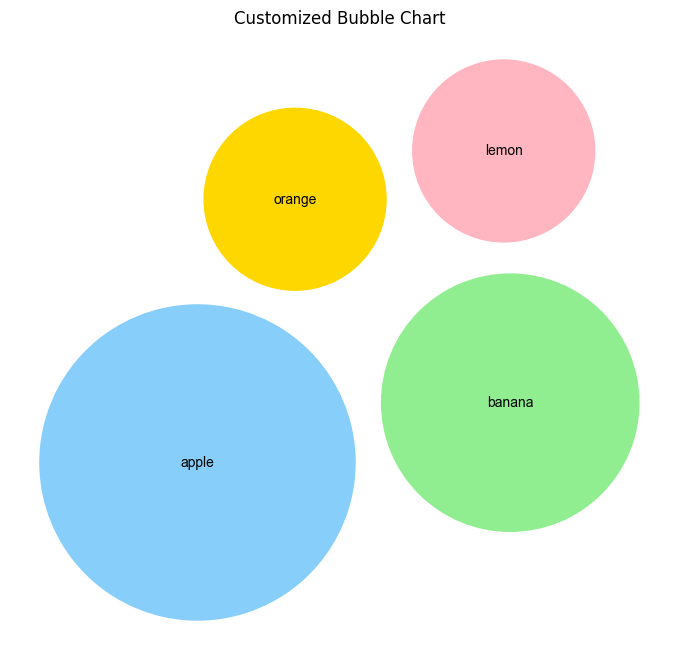

In [6]:
custom_colors = ["#FFB6C1", "#87CEFA", "#90EE90", "#FFD700"]

chart = BubbleChart(data=text)
chart(
    title="Customized Bubble Chart",
    limit=6,
    bubble_spacing=0.2,
    colors=custom_colors,
    font_family="Arial",
    figsize=(12, 8)
)


In [7]:
chart.save("bubble_chart.png")


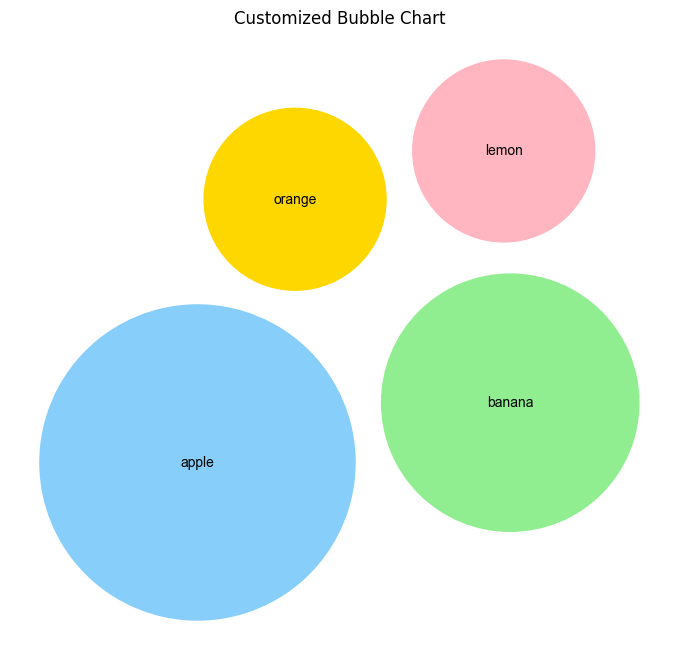

In [8]:
chart.show()


In [9]:
chart.close()


In [12]:
import en_core_web_sm
nlp = en_core_web_sm.load()


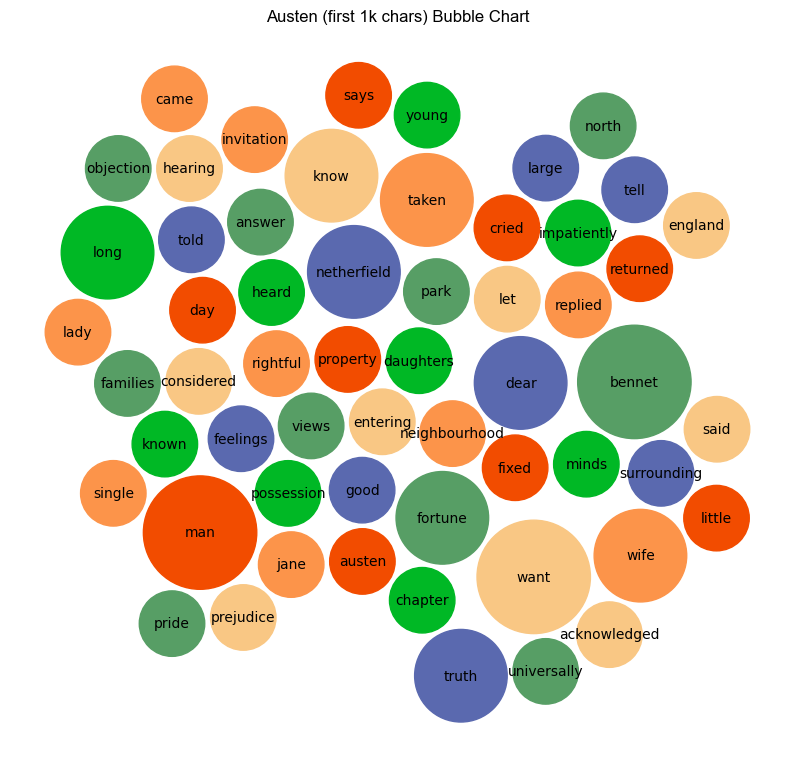

In [ ]:
from collections import Counter
from pathlib import Path

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from lexos.visualization.bubbleviz import BubbleChart

# --- 1. Load model and text ---
nlp = spacy.load("en_core_web_sm")
text = Path("docs/Austen_Pride.txt")\
    .read_text(encoding="utf-8")
doc = nlp(text[:1000])  # just a snippet for speed

# --- 2. Clean tokens & remove stopwords ---
tokens = [
    token.text.lower()
    for token in doc
    if token.is_alpha
    and token.text.lower() not in STOP_WORDS
]

# --- 3. Build frequency dict ---
counts = dict(Counter(tokens))

# --- 4. Render, customize, and save the bubble chart ---
chart = BubbleChart(
    data=counts,
    title="Austen (first 1k chars) Bubble Chart",
    limit=50,             # show top 50 terms
    bubble_spacing=0.15,  # a little extra breathing room
    figsize=(8, 8)
)
chart()                   # display inline
chart.save("austen_bubble_chart.png")


## Importance of Removing Stop Words in Text Visualization

Stop words are common words like "the", "and", "of", and "is" that appear frequently in most texts but carry very little meaningful content on their own. Including them in visualizations like bubble charts can clutter the output and obscure more significant terms.

By removing stop words, we focus the visualization on words that are more representative of the actual content and themes of the text. This makes the chart not only cleaner and easier to interpret, but also more insightful — especially when working with literary works, speeches, or open-ended survey responses.


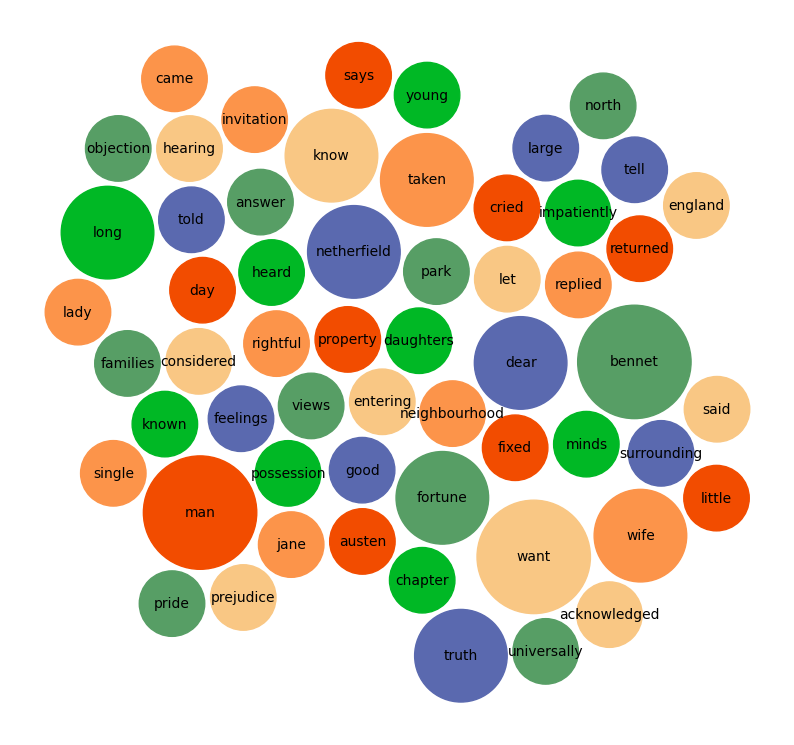

In [ ]:
from collections import Counter
from lexos.visualization.bubbleviz import BubbleChart
import spacy
from pathlib import Path

# Load spaCy and sample text
nlp = spacy.load("en_core_web_sm")
text = Path("docs/Austen_Pride.txt").read_text(encoding="utf-8")
doc = nlp(text[:1000])

# Clean and filter tokens: remove punctuation, spaces, stopwords, and non-alphabetic words
tokens = [
    token.text.lower()
    for token in doc
    if not token.is_punct and not token.is_space and not token.is_stop and token.is_alpha
]

# Frequency dict
counts = dict(Counter(tokens))

# Create and render chart
chart = BubbleChart(data=counts)
chart()


## 🔄 Interactive Bubble Chart with Top-N Control

This chart uses an interactive slider to control how many of the most frequent terms are displayed. The visualization updates live as you move the slider, allowing quick exploration of different word frequency thresholds in the text.


In [ ]:
from collections import Counter
from lexos.visualization.bubbleviz import BubbleChart
import spacy
from pathlib import Path
from ipywidgets import interact, IntSlider
import IPython.display as display

# Load spaCy and text
nlp = spacy.load("en_core_web_sm")
text = Path("docs/Austen_Pride.txt").read_text(encoding="utf-8")
doc = nlp(text[:1000])

# Preprocess and filter tokens
tokens = [
    token.text.lower()
    for token in doc
    if not token.is_punct and not token.is_space and not token.is_stop and token.is_alpha
]

# Frequency dict (all terms)
counts_full = dict(Counter(tokens))

# Function to update the chart interactively
def show_bubble_chart(top_n):
    # Get top N terms
    sorted_counts = dict(Counter(counts_full).most_common(top_n))
    chart = BubbleChart(data=sorted_counts)
    chart()

# Display slider
interact(show_bubble_chart, top_n=IntSlider(min=10, max=100, step=5, value=30, description='Top N Terms'))


interactive(children=(IntSlider(value=30, description='Top N Terms', min=10, step=5), Output()), _dom_classes=…

<function __main__.show_bubble_chart(top_n)>